# Augmentation – Day 1: Data & Domain

**Student Name:** Traver Dinten
**Country:** Switzerland
**Semester term:** FS26

## Use Case
*Focus: domain and application context*

In the context of satellite-based alpine glacier monitoring, multispectral imagery from the Sentinel-2 mission is used to track long-term glacier retreat, surface morphology, and structural changes across the European Alps. The European Space Agency's Sentinel-2 satellites capture surface reflectance data at 10 m spatial resolution in the visible spectrum, providing a systematic and freely available data source for environmental research. This use case is particularly relevant for Switzerland because the Aletsch Glacier — the largest glacier in the Alps and a UNESCO World Heritage site — serves as a key indicator for climate change impacts in the European Alpine region. Satellite-based monitoring enables consistent, large-scale observation independent of physical access to remote glacier terrain.

## Problem Statement
*Focus: technical vulnerability*

This project addresses the problem of applying non-geometric image augmentation to satellite glacier imagery within the context of glacier monitoring in Switzerland. Sentinel-2 images of alpine glaciers are subject to atmospheric degradation (haze, variable illumination due to terrain shadows) and sensor noise, which can reduce the visibility of critical structural features. If augmentation parameters such as brightness or noise levels are chosen inadequately, the ice-rock boundary — the primary structural feature used for glacier extent delineation — may become obscured or artificially amplified, leading to unreliable downstream analysis. Preserving the visibility and contrast of the transition zone between glacier ice, exposed rock, and snow cover is essential for accurate satellite-based glacier monitoring.

## Experimental Objective
*Focus: investigation goal at the conceptual level*

The objective of this project is to investigate how non-geometric augmentation operations — specifically brightness adjustment (gamma correction) and sensor noise simulation (Gaussian noise) — influence the visibility of structural features in Sentinel-2 satellite imagery of the Aletsch Glacier. The goal is to determine under which augmentation conditions the ice-rock boundary remains sufficiently distinguishable for reliable visual and automated analysis.

## Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection*

The selected image is a Sentinel-2 Level-2A Surface Reflectance composite of the upper Aletsch Glacier (Jungfraufirn region), acquired during summer 2023 (June–September). The composite was created by computing the per-pixel median across all cloud-free scenes in the date range, producing a representative, cloud-free view of the glacier surface. The image uses the visible bands B4 (Red), B3 (Green), and B2 (Blue) at 10 m spatial resolution, forming a true-colour RGB composite.

The data originate from the Copernicus Sentinel-2 mission operated by the European Space Agency (ESA), accessed via the Google Earth Engine platform (`COPERNICUS/S2_SR_HARMONIZED`). Sentinel-2 data are freely available under the Copernicus open data policy. The image is appropriate for this experiment because it provides a high-resolution, spectrally calibrated satellite view of the Aletsch Glacier with clearly identifiable structural features — including the ice-rock boundary, snow-covered firn areas, and exposed moraine deposits — suitable for image processing experiments.

In [3]:
import sys, os
sys.path.insert(0, os.path.join("..", "helpers"))

import numpy as np
import cv2
import matplotlib.pyplot as plt

DATA_DIR = os.path.join("..", "data", "raw")
IMAGE_PATH = os.path.join(DATA_DIR, "aletsch_jungfraufirn_s2.tif")

# --- Download via GEE only if not already cached ---
if not os.path.exists(IMAGE_PATH):
    from gee_utils import (
        init_gee, get_sentinel2_composite, download_sentinel2,
        ALETSCH_JUNGFRAUFIRN_BBOX,
    )
    init_gee("gbsvmc2")
    composite = get_sentinel2_composite(
        bbox=ALETSCH_JUNGFRAUFIRN_BBOX,
        date_start="2023-06-01",
        date_end="2023-09-30",
        max_cloud_pct=15,
    )
    download_sentinel2(
        image=composite,
        bbox=ALETSCH_JUNGFRAUFIRN_BBOX,
        filepath=IMAGE_PATH,
        bands=["B4", "B3", "B2"],
        scale=10,
    )
else:
    print(f"Image already cached: {IMAGE_PATH}")

from gee_utils import load_image
img_rgb = load_image(IMAGE_PATH)
print(f"Image shape: {img_rgb.shape}")
print(f"Value range: [{img_rgb.min()}, {img_rgb.max()}]")

Image already cached: ../data/raw/aletsch_jungfraufirn_s2.tif
Image shape: (446, 781, 3)
Value range: [0, 255]


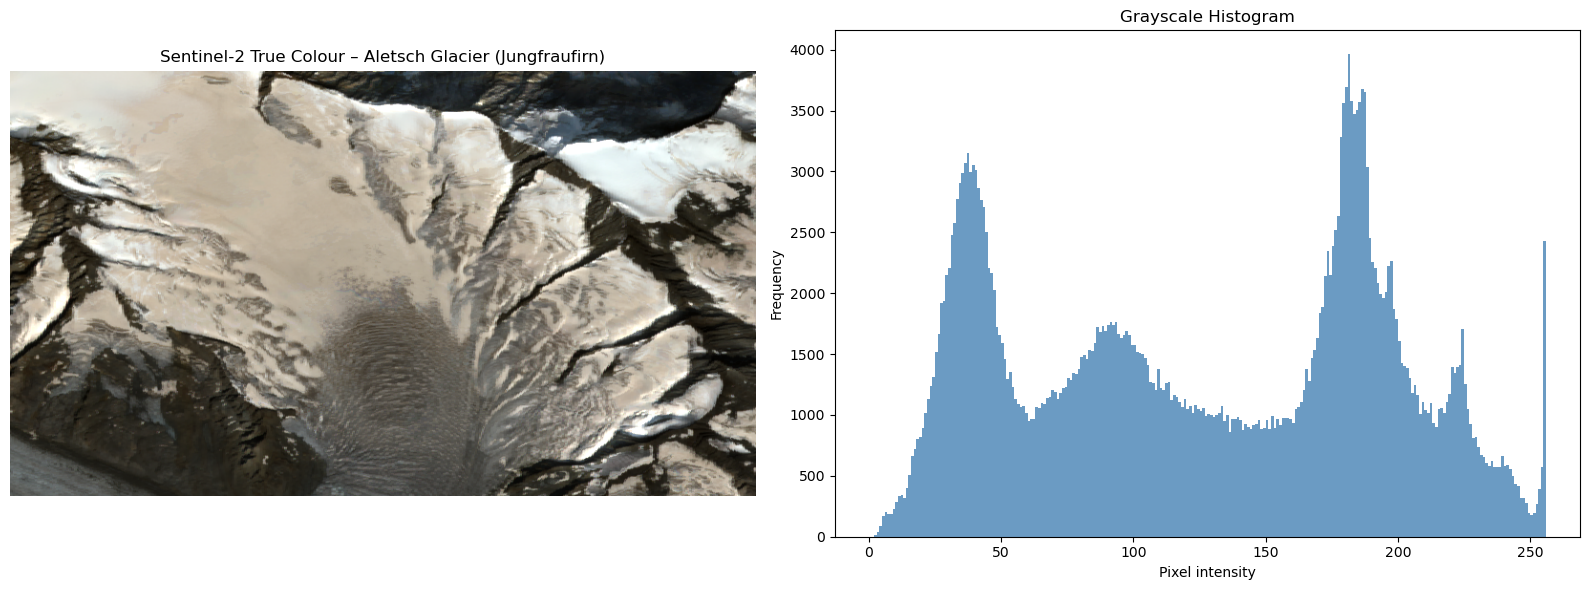

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Sentinel-2 True Colour – Aletsch Glacier (Jungfraufirn)")
axes[0].axis("off")

img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
axes[1].hist(img_gray.ravel(), bins=256, range=(0, 256), color="steelblue", alpha=0.8)
axes[1].set_title("Grayscale Histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**Observations:**

The Sentinel-2 true-colour composite shows the upper Aletsch Glacier with clear differentiation between snow-covered firn (bright), exposed glacier ice (grey-blue), and surrounding rock faces (dark brown/grey). The histogram reveals a bimodal distribution, reflecting the high contrast between bright snow/ice and dark rock surfaces. This intensity separation is the foundation for the augmentation experiments that follow.

## Structure Identification

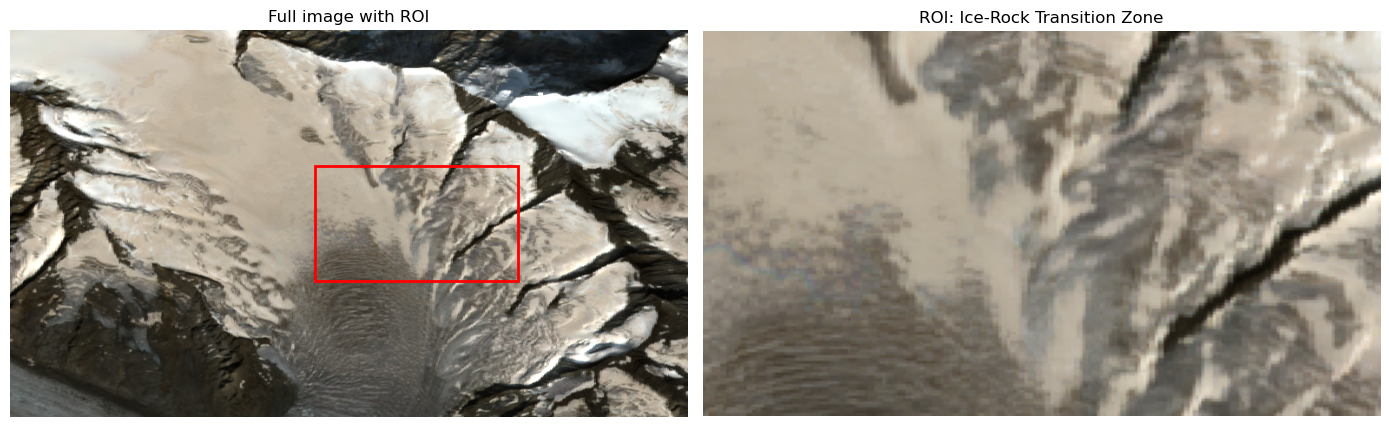

In [5]:
h, w = img_rgb.shape[:2]

# ROI: transition zone between ice and rock (approximate centre-right)
roi_y1, roi_y2 = int(h * 0.35), int(h * 0.65)
roi_x1, roi_x2 = int(w * 0.45), int(w * 0.75)

roi = img_rgb[roi_y1:roi_y2, roi_x1:roi_x2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_rgb)
import matplotlib.patches as patches
rect = patches.Rectangle(
    (roi_x1, roi_y1), roi_x2 - roi_x1, roi_y2 - roi_y1,
    linewidth=2, edgecolor="red", facecolor="none",
)
axes[0].add_patch(rect)
axes[0].set_title("Full image with ROI")
axes[0].axis("off")

axes[1].imshow(roi)
axes[1].set_title("ROI: Ice-Rock Transition Zone")
axes[1].axis("off")

plt.tight_layout()
plt.show()

The ROI highlights the transition zone between glacier ice and surrounding rock as observed from satellite altitude. In the 10 m resolution Sentinel-2 imagery, this boundary appears as a gradient between bright ice/snow pixels and darker rock pixels. This region will serve as the reference structure throughout the augmentation experiments: augmentation methods must preserve the visibility and contrast of this ice-rock boundary to remain useful for glacier extent delineation.

The challenge specific to satellite imagery is that atmospheric effects (haze, terrain shadows) and sensor noise can degrade this boundary in ways similar to the augmentations we will apply, making this a realistic test scenario for robustness assessment.